# Telco Customer Churn — Exploratory Data Analysis

This notebook explores the IBM Telco Customer Churn dataset to understand
the structure of the data, identify data quality issues, and surface
patterns that predict customer churn.

**Key questions we want to answer:**
- What is the overall churn rate, and is there a class imbalance?
- Which customer attributes are most strongly associated with churning?
- Are there any data quality issues we need to address before modelling?

The cleaned dataframe is saved at the end for use in `02_feature_engineering.ipynb`.


## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
%matplotlib inline


## 2. Load the data

We load the raw CSV and take an initial look at its shape, column types,
and the first few rows.


In [2]:
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()


Shape: 7,043 rows × 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Data types and schema

We inspect column dtypes to catch any surprises.
The `TotalCharges` column is a known gotcha in this dataset —
it is stored as an object (string) even though it should be numeric.
We'll fix that here so downstream analyses are correct.


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
# Fix TotalCharges: coerce to numeric (empty strings become NaN)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("TotalCharges dtype after fix:", df['TotalCharges'].dtype)


TotalCharges dtype after fix: float64


## 4. Missing values

After fixing `TotalCharges`, we check for any missing values across all columns.


In [5]:
missing = df.isnull().sum()
missing[missing > 0]


TotalCharges    11
dtype: int64

In [6]:
# TotalCharges NaNs correspond to customers with tenure=0 (brand-new customers).
# We'll drop these rows — they have no meaningful charge history.
print(f"Rows with NaN TotalCharges: {df['TotalCharges'].isnull().sum()}")
df = df.dropna(subset=['TotalCharges'])
print(f"Shape after dropping NaNs: {df.shape[0]:,} rows × {df.shape[1]} columns")


Rows with NaN TotalCharges: 11
Shape after dropping NaNs: 7,032 rows × 21 columns


## 5. Target variable — Churn rate and class balance

Understanding the class balance is critical before modelling.
An imbalanced target can mislead accuracy-based metrics and may require
techniques like class weighting or resampling.


In [7]:
# Encode target as binary
df['Churn_Binary'] = (df['Churn'] == 'Yes').astype(int)

churn_rate = df['Churn_Binary'].mean()
print(f"Overall churn rate: {churn_rate:.1%}")
print(df['Churn'].value_counts())


Overall churn rate: 26.6%
Churn
No     5163
Yes    1869
Name: count, dtype: int64


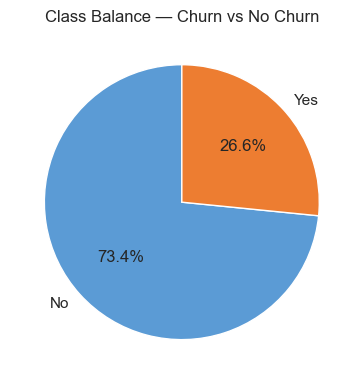

In [8]:
fig, ax = plt.subplots(figsize=(4, 4))
counts = df['Churn'].value_counts()
ax.pie(
    counts,
    labels=counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#5B9BD5', '#ED7D31'],
)
ax.set_title('Class Balance — Churn vs No Churn')
plt.tight_layout()
plt.savefig('../data/plots/class_balance.png', dpi=150)
plt.show()


**Finding:** The dataset is moderately imbalanced — roughly 26.5% of customers
churned. This is not severe enough to require aggressive resampling, but we
should use a metric like **AUC-ROC** or **F1** rather than raw accuracy when
evaluating models.


## 6. Numeric features vs Churn

We examine the three continuous features — `tenure`, `MonthlyCharges`,
and `TotalCharges` — split by churn status.


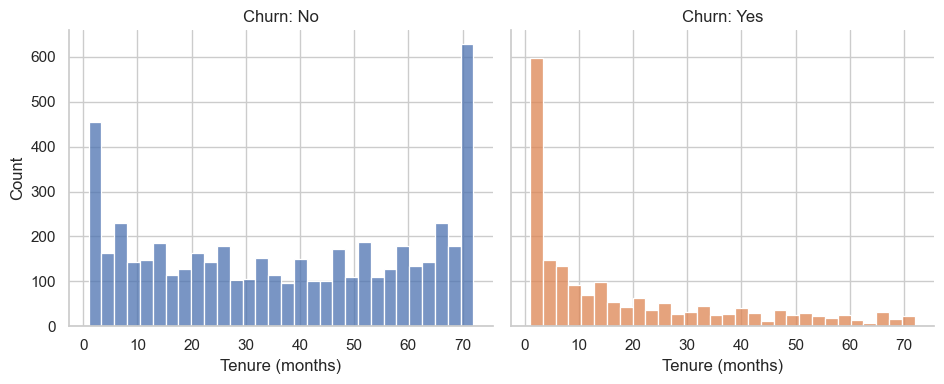

In [9]:
# Tenure
g = sns.FacetGrid(df, col='Churn', hue='Churn', height=4, aspect=1.2)
g.map(sns.histplot, 'tenure', bins=30)
g.set_axis_labels('Tenure (months)', 'Count')
g.set_titles(col_template='Churn: {col_name}')
plt.savefig('../data/plots/tenure_churn.png', dpi=150)
plt.show()


**Finding:** Churners are heavily skewed toward *short* tenures.
Non-churners show a more bimodal distribution — many brand-new customers
AND many long-tenured loyal customers stay. Tenure is likely our strongest
single predictor.


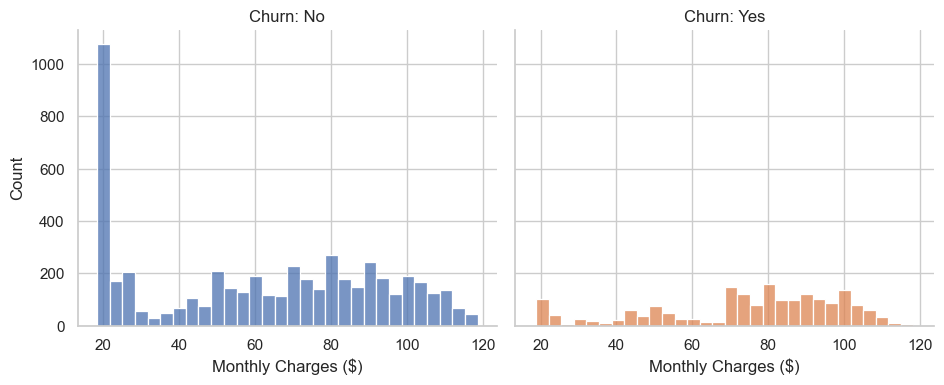

In [10]:
# Monthly Charges
g = sns.FacetGrid(df, col='Churn', hue='Churn', height=4, aspect=1.2)
g.map(sns.histplot, 'MonthlyCharges', bins=30)
g.set_axis_labels('Monthly Charges ($)', 'Count')
g.set_titles(col_template='Churn: {col_name}')
plt.savefig('../data/plots/monthly_charges_churn.png', dpi=150)
plt.show()


**Finding:** Churners tend to have *higher* monthly charges on average.
Non-churners show a large cluster of low-charge customers — these may be
on basic plans and are apparently quite sticky.


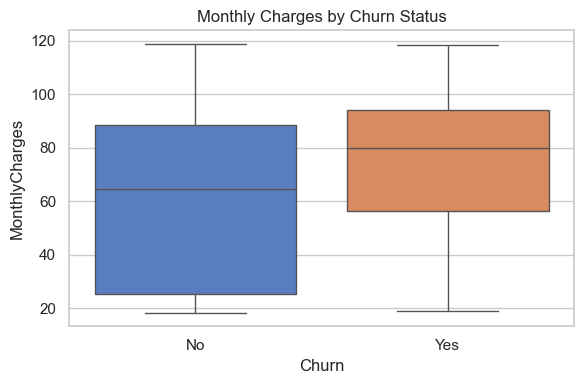

In [11]:
# Box plot: Monthly Charges by Churn
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', hue='Churn',
            legend=False, palette='muted', ax=ax)
ax.set_title('Monthly Charges by Churn Status')
plt.tight_layout()
plt.savefig('../data/plots/charges_boxplot.png', dpi=150)
plt.show()


## 7. Categorical features vs Churn

We compute churn rate for each categorical variable to identify
the highest-signal groups.


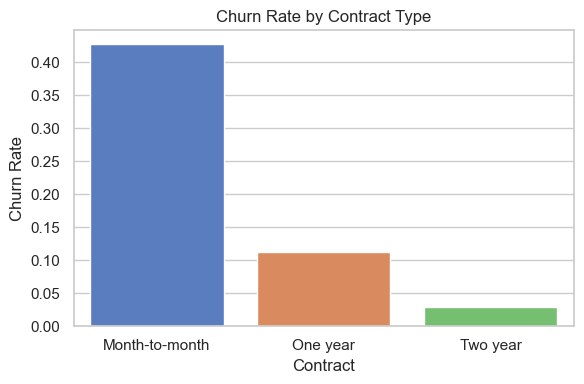

In [12]:
# Contract type
contract_churn = (df.groupby('Contract')['Churn_Binary']
                    .mean()
                    .reset_index()
                    .rename(columns={'Churn_Binary': 'Churn Rate'}))

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=contract_churn, x='Contract', y='Churn Rate',
            hue='Contract', legend=False, palette='muted', ax=ax)
ax.set_title('Churn Rate by Contract Type')
ax.set_ylabel('Churn Rate')
plt.tight_layout()
plt.savefig('../data/plots/contract_churn.png', dpi=150)
plt.show()


**Finding:** Month-to-month customers churn at ~42% — roughly 3× the rate
of customers on annual or two-year contracts. Contract type will be a key
feature for the model.


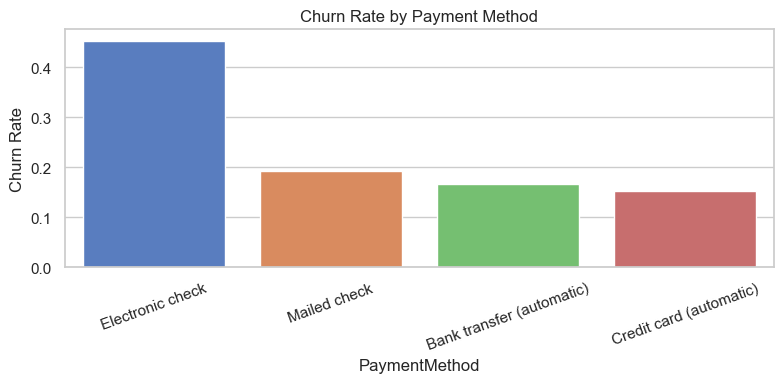

In [13]:
# Payment method
payment_churn = (df.groupby('PaymentMethod')['Churn_Binary']
                   .mean()
                   .sort_values(ascending=False)
                   .reset_index())

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=payment_churn, x='PaymentMethod', y='Churn_Binary',
            hue='PaymentMethod', legend=False, palette='muted', ax=ax)
ax.set_title('Churn Rate by Payment Method')
ax.set_ylabel('Churn Rate')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('../data/plots/payment_churn.png', dpi=150)
plt.show()


**Finding:** Electronic check users churn at ~45% — roughly double the
rate of customers using automatic payment methods. This likely reflects
lower commitment or financial friction rather than a causal relationship.


### 7.1 Systematic churn-rate summary for all categorical variables

Rather than plotting every column individually, we produce a ranked
summary table of churn rate by category value — useful for quickly
spotting high-risk segments.


In [14]:
cat_cols = df.select_dtypes(include='str').columns.drop(['customerID', 'Churn'])

rows = []
for col in cat_cols:
    for val, grp in df.groupby(col):
        rows.append({
            'Feature': col,
            'Value': val,
            'Churn Rate': grp['Churn_Binary'].mean(),
            'N': len(grp),
        })

summary = (pd.DataFrame(rows)
             .sort_values('Churn Rate', ascending=False)
             .reset_index(drop=True))

pd.set_option('display.max_rows', 60)
summary.head(30)


,Feature,Value,Churn Rate,N
0,PaymentMethod,Electronic check,0.452854,2365
1,Contract,Month-to-month,0.427097,3875
2,InternetService,Fiber optic,0.418928,3096
3,OnlineSecurity,No,0.417787,3497
4,TechSupport,No,0.416475,3472
5,OnlineBackup,No,0.399417,3087
6,DeviceProtection,No,0.391403,3094
7,StreamingMovies,No,0.337289,2781
8,PaperlessBilling,Yes,0.335893,4168
9,StreamingTV,No,0.335351,2809


## 8. Number of subscribed services vs Churn

A rough proxy for customer engagement is how many add-on services they
subscribe to (phone, internet, security, backup, etc.).
We compute this here for exploratory purposes; it will be engineered
properly in `02_feature_engineering.ipynb`.


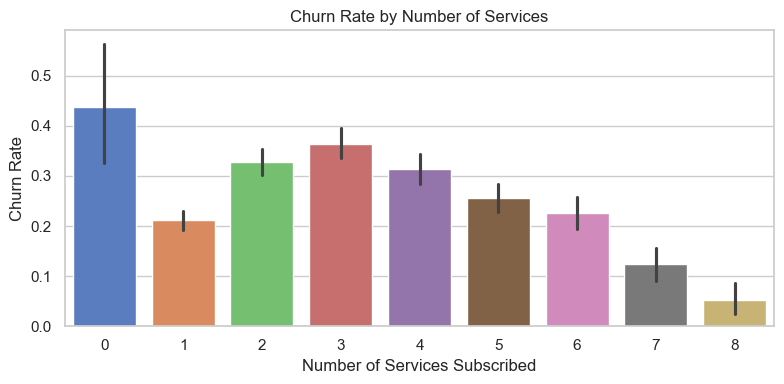

In [15]:
service_cols = ['PhoneService', 'MultipleLines',
                'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']

df['num_services'] = (df[service_cols] == 'Yes').sum(axis=1)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=df, x='num_services', y='Churn_Binary',
            hue='num_services', legend=False, palette='muted', ax=ax)
ax.set_title('Churn Rate by Number of Services')
ax.set_xlabel('Number of Services Subscribed')
ax.set_ylabel('Churn Rate')
plt.tight_layout()
plt.savefig('../data/plots/services_churn.png', dpi=150)
plt.show()


**Finding:** Customers with fewer services churn at a higher rate.
Customers subscribed to 5+ services are much more likely to stay —
possibly because switching costs are higher or because high engagement
correlates with satisfaction.


## 9. Correlation of numeric features with Churn

A quick Pearson correlation gives us a directional signal for the
numeric columns. Note that most of the predictive signal in this dataset
is in the categorical columns, which this matrix does not capture.


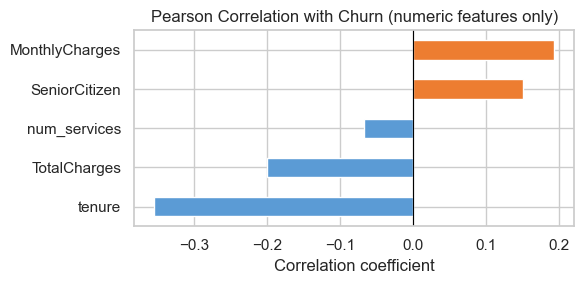

tenure           -0.354049
TotalCharges     -0.199484
num_services     -0.067459
SeniorCitizen     0.150541
MonthlyCharges    0.192858
Name: Churn_Binary, dtype: float64


In [16]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = (df[numeric_cols]
          .corr()['Churn_Binary']
          .drop('Churn_Binary')
          .sort_values())

fig, ax = plt.subplots(figsize=(6, 3))
corr.plot(kind='barh', ax=ax, color=['#ED7D31' if v > 0 else '#5B9BD5' for v in corr])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Pearson Correlation with Churn (numeric features only)')
ax.set_xlabel('Correlation coefficient')
plt.tight_layout()
plt.savefig('../data/plots/numeric_correlation.png', dpi=150)
plt.show()
print(corr)


**Finding:**
- `tenure` has the strongest (negative) correlation with churn: longer-tenured
  customers are much less likely to leave.
- `MonthlyCharges` is positively correlated: higher bills → more churn risk.
- `TotalCharges` is negatively correlated — but this largely reflects tenure
  (long-tenured customers accumulate high totals). These two features are
  collinear; we'll handle that in feature engineering.


## 10. EDA Summary and key takeaways

| Signal | Finding |
|--------|---------|
| Churn rate | 26.5% — moderate class imbalance; use AUC-ROC / F1 for evaluation |
| Tenure | Strongest numeric predictor; short tenure → high churn risk; corr: -0.354049 |
| Contract type | Month-to-month → 42.7% churn; one year → 11.3%; two year → 2.8% |
| Payment method | Electronic check → ~45% churn; automatic methods → ~15–20% |
| Monthly charges | Churners pay more on average; corr: 0.192858 |
| Services | Fewer services → higher churn risk |
| TotalCharges | Largely redundant with tenure; monitor for multicollinearity |

**Next steps (`02_feature_engineering.ipynb`):**
- Encode categorical variables
- Engineer `num_services` and `avg_charge_per_month`
- Handle the `tenure` / `TotalCharges` collinearity
- Scale numeric features for distance-based models


## 11. Save cleaned dataframe

Drop the temporary `num_services` column (will be re-engineered in notebook 02)
and save the cleaned, type-corrected dataframe for downstream use.


In [17]:
df_clean = df.drop(columns=['num_services'])
df_clean.to_csv('../data/telco_cleaned.csv', index=False)
print(f"Saved telco_cleaned.csv  ({df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns)")


Saved telco_cleaned.csv  (7,032 rows × 22 columns)
